In [1]:
%load_ext autoreload
%autoreload 2
import importlib 
m = importlib.import_module(".model", "src")
from matplotlib import pyplot as plt
import numpy as np
import xgi
import copy 
plt.style.use("seaborn-whitegrid")

import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

/tmp/ipykernel_364125/1168350578.py:9: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn-whitegrid")


In [5]:
dataset = "email-enron"
H = xgi.load_xgi_data(dataset)


In [19]:
def degree_sequence(H):
    return np.array(list(H.nodes.degree.asdict().values()))

def edge_size_sequence(H):
    return np.array(list(H.edges.size().asdict().values()))

# degree_sequence(H)
edge_size_sequence(H)

array([2, 3, 2, ..., 2, 2, 3])

Working on email-enron
Working on contact-high-school
Working on contact-primary-school
Working on diseasome
Working on disgenenet
Working on ndc-substances
Working on threads-ask-ubuntu
Working on tags-ask-ubuntu
Working on congress-bills
Working on coauth-mag-history
Working on coauth-mag-geology
Working on email-eu
Working on hospital-lyon
Working on hypertext-conference
Working on invs15
Working on science-gallery
Working on malawi-village
Working on sfhh-conference
Working on threads-math-sx
Working on ndc-classes


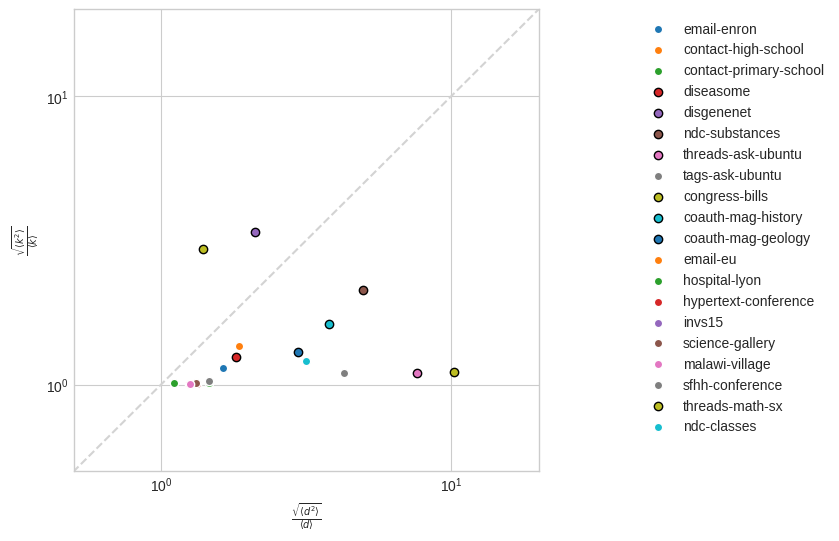

In [58]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

datasets = {
    "email-enron" : 1, 
    "contact-high-school" : 1, 
    "contact-primary-school" : 1, 
    "diseasome" : 0, 
    "disgenenet" : 0, 
    "ndc-substances" : 0, 
    "threads-ask-ubuntu" : 0, 
    "tags-ask-ubuntu" : 1,
    "congress-bills" : 0, 
    "coauth-mag-history" : 0, 
    "coauth-mag-geology" : 0, 
    "email-eu" : 1, 
    "hospital-lyon" : 1, 
    "hypertext-conference" : 1,
    "invs15" : 1,
    "science-gallery" : 1,
    "malawi-village" : 1, 
    "sfhh-conference" : 1, 
    "threads-math-sx" : 0,
    "ndc-classes"  : 1
    }

for dataset, toggle in datasets.items():
    print(f"Working on {dataset}")
    H = xgi.load_xgi_data(dataset)
    d = degree_sequence(H)
    k = edge_size_sequence(H)
    ax.scatter(np.sqrt((d**2).mean())/d.mean(), np.sqrt((k**2).mean())/k.mean(), label = dataset, edgecolors=["black", "white"][toggle])
    
ax_max = 2e1
ax.set_xlabel(r"$\frac{\sqrt{\langle d^2 \rangle}}{\langle d\rangle}$")
ax.set_ylabel(r"$\frac{\sqrt{\langle k^2 \rangle}}{\langle k\rangle}$")
ax.plot([0, ax_max], [0, ax_max], color = "lightgrey", linestyle = "--")
ax.set(xlim = (0.5, ax_max), ylim = (0.5, ax_max))
ax.loglog()
ax.legend(bbox_to_anchor=(1.2, 1.00))
